# Setup

In [1]:
%run notebook_setup.py

import pandas as pd
import numpy as np
from scipy.stats import trim_mean
import polars as pl
import pandas as pd
import logging
import gc

import matplotlib.pyplot as plt
import seaborn as sns

from src.config.dir_config import OUTPUT_PATH_DEMAND_SUMMARY
from src.config.bigquery_config import CREDENTIALS_GBQ, PROJECT_ID_GBQ
from src.utils.read_data import read_data
from src.utils.setup_logging import setup_logging
from src.utils.create_week_date import add_week_start_date
from src.utils.export_as_excel import export_dataframes_as_tables


import logging

setup_logging()

Now you can import modules from the project root: /bi/workspace/Projects/Forecast/forecast


# Functions

In [2]:
def clasifica_errores(
    df: pd.DataFrame,
    label: str,
    threshold: float = 0.35,        # tolerancia ±
    center: float = 1.0,            # centro del rango
    prop_prefix: str = "error_prop_forecast",
    out_prefix: str = "flag_error_forecast",
    kind_prefix: str = "tipo_error_forecast",
    copy: bool = False,
) -> pd.DataFrame:
    """
    Crea:
      - flag_error_forecast_{label} = 1 si |error_prop - center| <= threshold, si no 0 (NaN -> 0)
      - tipo_error_forecast_{label} ∈ {'sobreestimando', 'subestimando', 'en_rango', 'sin_dato'}
    """
    out = df.copy() if copy else df
    prop_col = f"{prop_prefix}_{label}"
    flag_col = f"{out_prefix}_{label}"
    kind_col = f"{kind_prefix}_{label}"

    prop = out[prop_col]

    # Flag 0/1
    out[flag_col] = (
        (prop - center).abs().le(threshold)   # dentro de [center-thr, center+thr]
        .fillna(False)                         # NaN -> 0
        .astype("UInt8")
    )

    # Clasificación sobre/sub/en_rango/sin_dato
    lower = center - threshold
    upper = center + threshold

    kind = pd.Series("ok", index=out.index)
    kind = kind.mask(prop.gt(upper), "sobreestimando")
    kind = kind.mask(prop.lt(lower), "subestimando")
    kind = kind.mask(prop.isna(), "sin venta")

    out[kind_col] = kind.astype("category")
    return out

In [3]:
def add_real_sales_sv(df):
    def var_forward_sum(g):
        g = g.sort_values("week_number")
        sales = g["weekly_sales"].fillna(0).to_numpy(int)
        weeks = g["semana_vta"].fillna(1).astype(int).to_numpy()
        n = len(sales)

        s = np.cumsum(sales)
        i = np.arange(n)
        right = np.minimum(i + weeks, n)
        s_pad = np.concatenate(([0.0], s))
        
        return pd.Series(s_pad[right] - s_pad[i], index=g.index)

    df["real_sales"] = (
    df
    .groupby(["cod_sucursal", "cod_producto", "cod_talla"], group_keys=False)[["week_number", "weekly_sales", "semana_vta"]]
    .apply(var_forward_sum)
    .astype("int16")
    )

    return df

In [4]:
def add_real_sales_n4(
    df: pd.DataFrame,
    sales_col: str = "weekly_sales",
    week_col: str = "week_number",
    ventana_col: str = "semana_vta",
    out_col: str = "real_sales_n4"
) -> pd.DataFrame:
    """
    Suma hacia adelante: semana actual + próximas (hasta) 3,
    usando una ventana por grupo = min(semana_vta, 4). 
    Crea la columna `out_col`.
    """
    def _roll_group(g: pd.DataFrame) -> pd.Series:
        g = g.sort_values(week_col)

        # ventana por grupo: min(semana_vta, 4), con piso 1
        v = g[ventana_col].iloc[0]
        w = int(max(1, min(int(v) if pd.notna(v) else 1, 4)))

        s = g[sales_col].fillna(0)
        # forward rolling: invertimos, aplicamos rolling(w), revertimos
        fwd = s.iloc[::-1].rolling(window=w, min_periods=1).sum().iloc[::-1]
        return fwd.reindex(g.index)

    df[out_col] = (
        df.groupby(["cod_sucursal", "cod_producto", "cod_talla"], group_keys=False)
          .apply(_roll_group)
          .astype("Int32")  # usa Int32/int64 si existe riesgo de overflow de int16
    )
    return df

In [5]:
def add_error_metrics(
    df: pd.DataFrame,
    forecast_col: str,
    real_col: str = "real_sales",
    label: str | None = None,
    copy: bool = False
) -> pd.DataFrame:
    """
    Calcula métricas de error para un forecast y agrega columnas:
      - error_{label}
      - error_prop_{label}
      - error_prop_rango_{label}
    
    Reglas:
      - error = forecast - real
      - error_prop = forecast / real (redondeado a 4 decimales)
      - Casos especiales en error_prop:
          * real=0 & forecast=0  -> 1.0
          * real=0 & forecast>0  -> NaN  (se etiqueta como 'Sin venta' en el rango)
      - Rangos ordenados:
          'igual a 0', 'entre 0 y 0.5', 'entre 0.5 y 0.9',
          'entre 0.9 y 1.1', 'entre 1.1 y 1.5', 'entre 1.5 y 2.0',
          '> 2.0', 'Sin venta', 'indefinido'

    Parámetros
    ----------
    df : DataFrame
    forecast_col : nombre de la columna de forecast a evaluar
    real_col : nombre de la columna de ventas reales (default 'real_sales')
    label : sufijo para las columnas generadas. Por defecto usa forecast_col.
    copy : si True, trabaja sobre una copia y la retorna
    """
    if copy:
        df = df.copy()

    lbl = label or forecast_col

    # 1) Columnas base
    forecast = df[forecast_col]
    real = df[real_col]
    
    # 2) error y proporción
    df[f"error_{lbl}"] = forecast - real
    error_prop = np.divide(forecast, real.replace(0, np.nan)).round(4)

    # 3) masks
    m_real0 = real == 0
    m_fore0 = forecast == 0

    # 4) Casos especiales
    error_prop = error_prop.copy()
    error_prop[m_real0 & m_fore0] = 1.0         # 0/0 -> 1.0
    error_prop[m_real0 & (~m_fore0)] = np.nan   # forecast>0 & real=0 -> NaN (bucket especial)

    df[f"error_prop_{lbl}"] = error_prop

    # 5) Rangos
    rangos = [
        "igual a 0",
        "entre 0 y 0.5",
        "entre 0.5 y 0.9",
        "entre 0.9 y 1.1",
        "entre 1.1 y 1.5",
        "entre 1.5 y 2.0",
        "> 2.0",
        "Sin venta"
    ]

    condlist = [
        (error_prop == 0).fillna(False).to_numpy(),
        ((error_prop > 0) & (error_prop <= 0.5)).fillna(False).to_numpy(),
        ((error_prop > 0.5) & (error_prop < 0.9)).fillna(False).to_numpy(),
        ((error_prop >= 0.9) & (error_prop <= 1.1)).fillna(False).to_numpy(),
        ((error_prop > 1.1) & (error_prop <= 1.5)).fillna(False).to_numpy(),
        ((error_prop > 1.5) & (error_prop <= 2.0)).fillna(False).to_numpy(),
        (error_prop > 2.0).fillna(False).to_numpy(),
        (m_real0 & (~m_fore0)).to_numpy(),  # Sin venta
    ]

    df[f"error_prop_rango_{lbl}"] = np.select(condlist, rangos, default="indefinido")
    df[f"error_prop_rango_{lbl}"] = pd.Categorical(
        df[f"error_prop_rango_{lbl}"],
        categories=rangos + ["indefinido"],
        ordered=True
    )

    return df

# Data import

In [6]:
data_genex = pd.read_parquet('../data/processed/genex_data_processed.parquet')
demand_summary = pd.read_parquet('../data/processed/demand_summary.parquet')
data_sales = pd.read_parquet('../data/processed/weekly_sales_by_season/Invierno/weekly_sales_Invierno_2025_processed.parquet')
classifications = pd.read_excel('../data/external/Consolidado clasificaciones modelo BI.xlsx')
transfers = pd.read_parquet('../data/processed/trf_data_processed.parquet')

# Data processing

In [7]:
data_sales = data_sales[data_sales['cod_sucursal'] != 767]
demand_summary = demand_summary[demand_summary['cod_sucursal'] != 767]
demand_summary = demand_summary[demand_summary['nombre_depto'] != 'Bolsas y bolsos']
demand_summary = demand_summary[demand_summary['nombre_depto'] != 'Miscelaneos']
demand_summary = demand_summary[demand_summary['nombre_temporada'] == 'Invierno']
demand_summary = demand_summary[demand_summary['ano_temporada'] == '2025']

In [8]:
demand_info = demand_summary[['cod_producto', 'cod_talla', 'cod_sucursal',
                              'nombre_sucursal',
                              'nombre_temporada','ano_temporada','nombre_depto','nombre_linea','nom_talla',
                              'demand_type']].copy()

In [9]:
transfers_pivot = transfers.pivot_table(
    index=['cod_sucursal','cod_producto','cod_talla','cod_ano_comercial','cod_semana'],
    observed=True,
    columns="nombre_razon_group",
    values= 'cantidad_des',
    aggfunc="sum",
    fill_value=0
).reset_index()

transfers_pivot.columns.name = None

In [10]:
transfers_pivot_summary = transfers.pivot_table(
    index=['cod_sucursal','cod_producto','cod_talla'],
    observed=True,
    columns="nombre_razon_group",
    values= 'cantidad_des',
    aggfunc="sum",
    fill_value=0
).reset_index()

transfers_pivot_summary.columns.name = None

In [11]:
demand_summary = demand_summary.merge(
    transfers_pivot_summary,
    on = ['cod_sucursal','cod_producto','cod_talla'],
    how = 'left'
)

demand_summary[["PREDISTRIBUIDA",
        "REPOSICION AUTOMATIC",
        "CARGA MANUAL",
        "OTRAS"]] = demand_summary[["PREDISTRIBUIDA",
                                    "REPOSICION AUTOMATIC",
                                    "CARGA MANUAL",
                                    "OTRAS"]].fillna(0)

## *A) Proccessing data_all*

In [12]:
data_all = data_sales.merge(data_genex,
                            on=['cod_producto','cod_talla', 'cod_sucursal', 'cod_ano_comercial','cod_semana'],
                                how='left')

data_all = data_all.merge(demand_info,
                            on=['cod_producto','cod_talla', 'cod_sucursal'],
                            how='left')

data_all = data_all.merge(classifications,
                            on=['nombre_temporada','cod_sucursal','nombre_depto', 'nombre_linea'],
                            how='left')

data_all = data_all.merge(transfers_pivot,
                            on=['cod_producto','cod_talla', 'cod_sucursal', 'cod_ano_comercial','cod_semana'],
                                how='left')

del demand_info, classifications, data_sales
gc.collect()

35358

In [13]:
data_all = add_week_start_date(data_all)

In [14]:
data_all['clasificacion'] = pd.Categorical(data_all['clasificacion'],
                                           categories=['AA','A','B','C'],
                                           ordered=True)

In [15]:
data_all['factor_l_dias'] = np.where(
    data_all['mean_sales_past_4_weeks'] == 0,
    np.nan,
    (data_all['vta_promedio'] / data_all['mean_sales_past_4_weeks']).round(3)
)

In [16]:
data_all[["PREDISTRIBUIDA",
        "REPOSICION AUTOMATIC",
        "CARGA MANUAL",
        "OTRAS"]] = data_all[["PREDISTRIBUIDA",
                                    "REPOSICION AUTOMATIC",
                                    "CARGA MANUAL",
                                    "OTRAS"]].fillna(0)

In [17]:
data_all = add_real_sales_sv(data_all)

In [18]:
data_all = add_real_sales_n4(data_all)

/tmp/ipykernel_2867124/3702528945.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_roll_group)


In [ ]:
data_all.to_parquet('../sandbox/data_genex_venta_transfer.parquet')

In [ ]:
data_all = pd.read_parquet('../sandbox/data_genex_venta_transfer.parquet')

# *b) Modelación escenarios*

Forecast actual

In [19]:
data_all['forecast_tricot'] = (data_all['vta_promedio'] * data_all['factor'] * data_all['semana_vta']).fillna(0).round(0).astype('UInt16')

data_all = add_error_metrics(data_all,
                             forecast_col="forecast_tricot",
                             real_col="real_sales")

data_all = clasifica_errores(data_all, label="tricot")

Forecast vta_promedio = 1

In [20]:
data_all['forecast_vta_promedio'] = (np.minimum(data_all['vta_promedio'], 1) * data_all['factor'] * data_all['semana_vta']).fillna(0).round(0).astype('UInt16')

data_all = add_error_metrics(data_all,
                             forecast_col="forecast_vta_promedio",
                             real_col="real_sales")

data_all = clasifica_errores(data_all, label="vta_promedio")

Forecast vta_promedio = 1 y Factor = 1

In [21]:
data_all['forecast_vta_promedio_f1'] = (np.minimum(data_all['vta_promedio'], 1) * 1 * data_all['semana_vta']).fillna(0).round(0).astype('UInt16')

data_all = add_error_metrics(data_all,
                             forecast_col="forecast_vta_promedio_f1",
                             real_col="real_sales")

data_all = clasifica_errores(data_all, label="vta_promedio_f1")

Forecast SV = 4

In [22]:
data_all['forecast_sv4'] = (data_all['vta_promedio'] * data_all['factor'] * np.minimum(data_all['semana_vta'], 4)).fillna(0).round(0).astype('UInt16')


data_all = add_error_metrics(data_all,
                             forecast_col="forecast_sv4",
                             real_col="real_sales_n4")

data_all = clasifica_errores(data_all, label="sv4")

Factor 1

In [23]:
data_all['forecast_f1'] = (data_all['vta_promedio'] * 1 * data_all['semana_vta']).fillna(0).round(0).astype('UInt16')

data_all = add_error_metrics(data_all,
                             forecast_col="forecast_f1",
                             real_col="real_sales")

data_all = clasifica_errores(data_all, label="f1")

Forecast SV=4 y Factor 1

In [24]:
data_all['forecast_sv4_f1'] = (data_all['vta_promedio'] * 1 * np.minimum(data_all['semana_vta'], 4)).fillna(0).round(0).astype('UInt16')

data_all = add_error_metrics(data_all,
                             forecast_col="forecast_sv4_f1",
                             real_col="real_sales_n4")

data_all = clasifica_errores(data_all, label="sv4_f1")

# EDA

## Sample product

In [25]:
list(data_all.columns)

['cod_sucursal',
 'cod_producto',
 'cod_talla',
 'cod_sku',
 'cod_ano_comercial',
 'cod_semana',
 'mnt_precio_base',
 'mnt_precio_vigente',
 'weekly_sales',
 'stock_start_week',
 'stock_end_week',
 'mnt_venta_neta',
 'mnt_costo_venta',
 'week_number',
 'reposition',
 'cumulative_sales',
 'weekly_available_stock',
 'mean_sales_past_4_weeks',
 'mean_sales_next_4_weeks',
 'flag_sku_arrival',
 'flag_sale',
 'flag_inventory_available',
 'flag_repo',
 'flag_stockout',
 'flag_without_first_sale',
 'vta_periodo',
 'vta_promedio',
 'semana_vta',
 'ume',
 'factor',
 'stock_on_hand',
 'stock_sucursal',
 'stock_bodega',
 'repo_x_ume',
 'repo_x_dda',
 'can_original',
 'can_final',
 'estado',
 'clasif',
 'valida_formula_repo',
 'nombre_sucursal',
 'nombre_temporada',
 'ano_temporada',
 'nombre_depto',
 'nombre_linea',
 'nom_talla',
 'demand_type',
 'clasificacion',
 'PREDISTRIBUIDA',
 'REPOSICION AUTOMATIC',
 'CARGA MANUAL',
 'OTRAS',
 'date',
 'factor_l_dias',
 'real_sales',
 'real_sales_n4',
 'for

In [26]:
cod_producto = 680279

data_sample = data_all[data_all['cod_producto'] == cod_producto].copy()

interest_columns = ['cod_sucursal','nombre_sucursal',
                    'nombre_depto','nombre_linea','cod_producto', 'cod_talla', 'nom_talla',
                    'date','week_number',
                    'mnt_precio_vigente','weekly_available_stock','weekly_sales',
                    'vta_promedio','factor','semana_vta', 'ume','repo_x_dda','repo_x_ume','can_original','can_final',
                    'real_sales', 'forecast_tricot','forecast_f1', 'forecast_vta_promedio',
                    'real_sales_n4','forecast_sv4','forecast_sv4_f1',
                    'error_prop_forecast_tricot','error_prop_forecast_f1','error_prop_forecast_sv4','error_prop_forecast_sv4_f1',
                    'tipo_error_forecast_tricot',
                    'tipo_error_forecast_f1',
                    'tipo_error_forecast_sv4',
                    'tipo_error_forecast_sv4_f1',
                    'valida_formula_repo','estado','clasif',
                     "PREDISTRIBUIDA","REPOSICION AUTOMATIC","CARGA MANUAL","OTRAS",]


data_sample = data_sample[interest_columns].round(2).reset_index(drop=True)

In [27]:
data_sample.query('cod_talla == 105 and cod_sucursal == 14 and can_final>0').head()

,cod_sucursal,nombre_sucursal,nombre_depto,nombre_linea,cod_producto,cod_talla,nom_talla,date,week_number,mnt_precio_vigente,...,tipo_error_forecast_f1,tipo_error_forecast_sv4,tipo_error_forecast_sv4_f1,valida_formula_repo,estado,clasif,PREDISTRIBUIDA,REPOSICION AUTOMATIC,CARGA MANUAL,OTRAS
833,14,OSORNO,Juvenil mujer,Poleras manga larga,680279,105,L,2025-03-24,2,9990.0,...,sobreestimando,sobreestimando,sobreestimando,True,REPONER,BOTTOM INTELIGENTE,0,38,0,0
834,14,OSORNO,Juvenil mujer,Poleras manga larga,680279,105,L,2025-03-31,3,9990.0,...,sobreestimando,sin venta,sin venta,True,REPONER,BOTTOM INTELIGENTE,0,0,0,0


In [28]:
data_sample.query('cod_talla == 105 and cod_sucursal == 14 and can_final>0')[
                    ['date','weekly_sales','real_sales',
                    'forecast_tricot','forecast_f1','real_sales_n4','forecast_sv4','forecast_sv4_f1',
                    'error_prop_forecast_tricot','error_prop_forecast_f1','error_prop_forecast_sv4','error_prop_forecast_sv4_f1',]
                    ].reset_index()

,index,date,weekly_sales,real_sales,forecast_tricot,forecast_f1,real_sales_n4,forecast_sv4,forecast_sv4_f1,error_prop_forecast_tricot,error_prop_forecast_f1,error_prop_forecast_sv4,error_prop_forecast_sv4_f1
0,833,2025-03-24,1,3,34,24,1,17,12,11.33,8.0,17.0,12.0
1,834,2025-03-31,0,2,52,21,0,26,10,26.0,10.5,<NA>,<NA>


In [29]:
demand_summary_sample = demand_summary[demand_summary['cod_producto'] == cod_producto].copy()

In [30]:
dataframes = {
    f"{cod_producto}_sale": data_sample,
    f"{cod_producto}_summary":demand_summary_sample
    }

export_dataframes_as_tables(
    dataframes,
    f'../sandbox/{cod_producto}.xlsx'
)

2025-08-20 17:40:11,104 - INFO - DataFrame '680279_sale' has 9024 rows and 42 columns.
2025-08-20 17:40:11,105 - INFO - DataFrame '680279_summary' has 412 rows and 36 columns.


## Sample sandbox

In [31]:
data_all.query('can_final > 0 and repo_x_dda > 0').groupby('week_number')[['forecast_tricot', 'real_sales','repo_x_dda','can_final']].sum()

,forecast_tricot,real_sales,repo_x_dda,can_final
week_number,,,,
1,3917,2304,2912.0,2404.0
2,551013,276532,417885.0,324299.0
3,932061,390575,480804.0,391332.0
4,640474,264099,248539.0,213500.0
5,457874,199146,159122.0,136808.0
6,638187,259579,238555.0,191900.0
7,707059,241810,212117.0,164174.0
8,383985,161777,148654.0,119973.0
9,302964,122863,99743.0,81308.0


# **Calculo error forecast cuando hay repo por demanda**

In [32]:
filtro = "can_final > 0 and repo_x_dda > 0 and repo_x_dda >= repo_x_ume"

data_repo_x_dda = data_all.query(filtro).copy()

## *A) Por rango proporcion del error*

In [33]:
error_prop_rango = data_repo_x_dda.pivot_table(
    index='week_number',
    columns='error_prop_rango_forecast_tricot',
    values='can_final',
    aggfunc='sum',
    observed=True
) / data_repo_x_dda['can_final'].sum()

error_prop_rango = error_prop_rango.reset_index()

error_prop_rango.round(2)

error_prop_rango_forecast_tricot,week_number,igual a 0,entre 0 y 0.5,entre 0.5 y 0.9,entre 0.9 y 1.1,entre 1.1 y 1.5,entre 1.5 y 2.0,> 2.0,Sin venta
0,1,NaN,0.0,0.00,0.00,0.00,0.00,0.00,0.00
1,2,0.0,0.0,0.01,0.02,0.02,0.03,0.09,0.01
2,3,0.0,0.0,0.01,0.02,0.03,0.03,0.11,0.01
3,4,0.0,0.0,0.01,0.01,0.02,0.02,0.05,0.01
4,5,0.0,0.0,0.01,0.01,0.01,0.01,0.03,0.01
5,6,0.0,0.0,0.01,0.01,0.02,0.01,0.05,0.01
6,7,0.0,0.0,0.01,0.01,0.01,0.01,0.04,0.01
7,8,NaN,0.0,0.00,0.01,0.01,0.01,0.03,0.00
8,9,NaN,0.0,0.00,0.00,0.01,0.01,0.02,0.00
9,10,0.0,0.0,0.00,0.00,0.01,0.01,0.02,0.00


In [71]:
data_repo_x_dda.columns

Index(['cod_sucursal', 'cod_producto', 'cod_talla', 'cod_sku',
       'cod_ano_comercial', 'cod_semana', 'mnt_precio_base',
       'mnt_precio_vigente', 'weekly_sales', 'stock_start_week',
       'stock_end_week', 'mnt_venta_neta', 'mnt_costo_venta', 'week_number',
       'reposition', 'cumulative_sales', 'weekly_available_stock',
       'mean_sales_past_4_weeks', 'mean_sales_next_4_weeks',
       'flag_sku_arrival', 'flag_sale', 'flag_inventory_available',
       'flag_repo', 'flag_stockout', 'flag_without_first_sale', 'vta_periodo',
       'vta_promedio', 'semana_vta', 'ume', 'factor', 'stock_on_hand',
       'stock_sucursal', 'stock_bodega', 'repo_x_ume', 'repo_x_dda',
       'can_original', 'can_final', 'estado', 'clasif', 'valida_formula_repo',
       'nombre_sucursal', 'nombre_temporada', 'ano_temporada', 'nombre_depto',
       'nombre_linea', 'nom_talla', 'demand_type', 'clasificacion',
       'PREDISTRIBUIDA', 'REPOSICION AUTOMATIC', 'CARGA MANUAL', 'OTRAS',
       'date', 'fac

In [83]:
error_prop_summary= data_repo_x_dda.groupby(['week_number'], as_index = False).agg(
    can_final =  ('can_final','sum'),
    vta_promedio_mean = ('vta_promedio','mean'),
    factor_mean = ('factor', 'mean'),
    semana_vta_mean = ('semana_vta', 'mean'),
    forecast_tricot_mean = ('forecast_tricot','mean'),
    real_sales_mean = ('real_sales','mean'),
    repo_x_dda_mean = ('repo_x_dda','mean'),
    can_final_mean = ('can_final','mean'),
    error_prop_tricot = ('error_prop_forecast_tricot', 'mean'),
    error_prop_vta_promedio = ('error_prop_forecast_vta_promedio_f1', 'mean'),
    error_prop_vta_promedio_f1 = ('error_prop_forecast_vta_promedio','mean'),
    error_prop_forecast_vta_promedio_f1 = ('error_prop_forecast_vta_promedio_f1','mean'),
    error_prop_sv4 = ('error_prop_forecast_sv4', 'mean'),
    error_prop_f1 = ('error_prop_forecast_f1', 'mean'),
    error_prop_sv4_f1 = ('error_prop_forecast_sv4_f1', 'mean'),
    flag_error_forecast_tricot_mean  = ('flag_error_forecast_tricot', 'mean'),
    flag_error_forecast_f1_mean = ('flag_error_forecast_f1', 'mean'),
    flag_error_forecast_sv4_mean = ('flag_error_forecast_sv4', 'mean'),
    flag_error_forecast_sv4_f1_mean = ('flag_error_forecast_sv4_f1', 'mean'),
    flag_error_forecast_vta_promedio_mean = ('flag_error_forecast_vta_promedio', 'mean'),
    flag_error_forecast_vta_promedio_f1_mean = ('flag_error_forecast_vta_promedio_f1', 'mean')
)

error_prop_summary['can_final_prop'] = error_prop_summary['can_final'] / error_prop_summary['can_final'].sum()


COLUMNS_ORDER = ['week_number',
                 'can_final_prop','can_final', 'can_final_mean',
                 'vta_promedio_mean', 'factor_mean', 'semana_vta_mean',
                 'forecast_tricot_mean', 'real_sales_mean',
                 'error_prop_tricot','error_prop_sv4','error_prop_f1','error_prop_vta_promedio_f1', 'error_prop_sv4_f1','error_prop_vta_promedio',
                 'flag_error_forecast_tricot_mean','flag_error_forecast_vta_promedio_mean','flag_error_forecast_f1_mean','flag_error_forecast_vta_promedio_f1_mean', 'flag_error_forecast_sv4_mean','flag_error_forecast_sv4_f1_mean']

error_prop_summary = error_prop_summary[COLUMNS_ORDER]

error_prop_summary.head(12).round(2)

,week_number,can_final_prop,can_final,can_final_mean,vta_promedio_mean,factor_mean,semana_vta_mean,forecast_tricot_mean,real_sales_mean,error_prop_tricot,...,error_prop_f1,error_prop_vta_promedio_f1,error_prop_sv4_f1,error_prop_vta_promedio,flag_error_forecast_tricot_mean,flag_error_forecast_vta_promedio_mean,flag_error_forecast_f1_mean,flag_error_forecast_vta_promedio_f1_mean,flag_error_forecast_sv4_mean,flag_error_forecast_sv4_f1_mean
0,1,0.00,2363.0,5.59,0.98,1.39,7.09,9.09,5.22,2.41,...,1.82,1.99,1.63,1.5,0.32,0.36,0.34,0.37,0.26,0.29
1,2,0.18,324071.0,8.34,1.51,1.30,7.27,14.15,7.09,3.25,...,2.59,2.45,2.89,1.96,0.27,0.32,0.33,0.37,0.16,0.21
2,3,0.22,389451.0,6.17,1.37,1.40,7.46,14.66,6.09,3.43,...,2.54,2.38,2.95,1.79,0.26,0.32,0.32,0.37,0.12,0.16
3,4,0.12,210311.0,4.69,1.25,1.47,7.40,14.03,5.68,3.14,...,2.23,2.25,2.82,1.64,0.28,0.32,0.3,0.33,0.12,0.16
4,5,0.07,131913.0,4.28,1.27,1.60,7.25,14.34,6.08,3.07,...,2.04,2.24,2.63,1.46,0.29,0.32,0.34,0.35,0.11,0.16
5,6,0.10,187743.0,4.78,1.41,1.58,7.24,15.95,6.36,3.37,...,2.25,2.34,2.78,1.57,0.27,0.3,0.33,0.35,0.12,0.16
6,7,0.09,158844.0,5.02,1.81,1.63,7.26,21.85,7.33,3.54,...,2.35,2.35,3.2,1.54,0.25,0.29,0.33,0.34,0.11,0.15
7,8,0.06,114948.0,4.92,1.51,1.63,6.98,16.01,6.57,3.56,...,2.37,2.35,3.03,1.51,0.27,0.3,0.34,0.34,0.12,0.17
8,9,0.04,78811.0,4.85,1.69,1.65,7.04,18.22,7.23,3.47,...,2.28,2.35,3.24,1.5,0.25,0.28,0.32,0.32,0.1,0.15
9,10,0.04,63916.0,5.41,2.25,1.61,6.96,25.33,8.69,3.95,...,2.61,2.3,3.71,1.5,0.25,0.27,0.33,0.32,0.11,0.17


In [84]:
error_prop_cat= data_repo_x_dda.groupby(['nombre_depto','nombre_linea','week_number'], as_index = False).agg(
    vta_promedio_mean = ('vta_promedio','mean'),
    factor_mean = ('factor', 'mean'),
    semana_vta_mean = ('semana_vta', 'mean'),
    forecast_tricot_mean = ('forecast_tricot','mean'),
    real_sales_mean = ('real_sales','mean'),
    repo_x_dda_mean = ('repo_x_dda','mean'),
    can_final_mean = ('can_final','mean'),
    error_prop_tricot = ('error_prop_forecast_tricot', 'mean'),
    error_prop_sv4 = ('error_prop_forecast_sv4', 'mean'),
    error_prop_f1 = ('error_prop_forecast_f1', 'mean'),
    error_prop_sv4_f1 = ('error_prop_forecast_sv4_f1', 'mean'),
    can_final =  ('can_final','sum')
)

error_prop_cat['can_final_prop'] = error_prop_cat['can_final'] / error_prop_cat.groupby(['nombre_depto','nombre_linea'])['can_final'].transform('sum')

COLUMNS_ORDER = ['nombre_depto','nombre_linea','week_number',
                 'can_final_prop','can_final',
                 'vta_promedio_mean', 'factor_mean', 'semana_vta_mean',
                 'forecast_tricot_mean', 'real_sales_mean']


error_prop_cat = error_prop_cat[COLUMNS_ORDER]

In [85]:
error_prod= data_repo_x_dda.groupby(['nombre_depto','nombre_linea','cod_producto','cod_talla','week_number'], as_index = False).agg(
    sucursales = ('nombre_sucursal', 'nunique'),
    vta_promedio_mean = ('vta_promedio','mean'),
    factor_mean = ('factor', 'mean'),
    semana_vta_mean = ('semana_vta', 'mean'),
    forecast_tricot_mean = ('forecast_tricot','mean'),
    real_sales_mean = ('real_sales','mean'),
    repo_x_dda_mean = ('repo_x_dda','mean'),
    can_final_mean = ('can_final','mean'),
    error_prop_tricot = ('error_prop_forecast_tricot', 'mean'),
    error_prop_sv4 = ('error_prop_forecast_sv4', 'mean'),
    error_prop_f1 = ('error_prop_forecast_f1', 'mean'),
    error_prop_sv4_f1 = ('error_prop_forecast_sv4_f1', 'mean'),
    can_final =  ('can_final','sum')
).query('cod_producto == 680279 and cod_talla == 105')

error_prod['can_final_prop'] = error_prod['can_final'] / error_prod.groupby(['nombre_depto','nombre_linea','cod_producto','cod_talla'])['can_final'].transform('sum')

COLUMNS_ORDER = ['nombre_depto','nombre_linea', 'cod_producto','cod_talla', 'week_number',
                 'sucursales','can_final_prop','can_final',
                 'vta_promedio_mean', 'factor_mean', 'semana_vta_mean',
                 'forecast_tricot_mean', 'real_sales_mean', 'error_prop_tricot']

error_prod = error_prod[COLUMNS_ORDER]

error_prod.round(2)

,nombre_depto,nombre_linea,cod_producto,cod_talla,week_number,sucursales,can_final_prop,can_final,vta_promedio_mean,factor_mean,semana_vta_mean,forecast_tricot_mean,real_sales_mean,error_prop_tricot
25268,Juvenil mujer,Poleras manga larga,680279,105,2,20,0.74,403.0,2.40,1.48,8.0,28.8,11.80,2.98
25269,Juvenil mujer,Poleras manga larga,680279,105,3,25,0.26,144.0,2.84,2.86,8.0,65.0,10.44,8.39
25270,Juvenil mujer,Poleras manga larga,680279,105,8,1,0.00,1.0,2.50,2.00,8.0,40.0,1.00,40.0


In [86]:
dataframes = {
    "error_prop_rango": error_prop_rango,
    "error_prop_summary": error_prop_summary,
    "error_prop_cat": error_prop_cat.round(2),
    'error_codigo': error_prod.round(2)
}


export_dataframes_as_tables(
    dataframes,
    '../sandbox/errores.xlsx'
)

2025-08-20 17:50:04,860 - INFO - DataFrame 'error_prop_rango' has 34 rows and 9 columns.
2025-08-20 17:50:04,861 - INFO - DataFrame 'error_prop_summary' has 34 rows and 21 columns.
2025-08-20 17:50:04,861 - INFO - DataFrame 'error_prop_cat' has 1788 rows and 10 columns.
2025-08-20 17:50:04,861 - INFO - DataFrame 'error_codigo' has 3 rows and 14 columns.


# **Analisis**

In [87]:
graph = (
    error_prop_summary
    .copy()
    .set_index('week_number')
).query('week_number >= 2 and week_number <= 8')

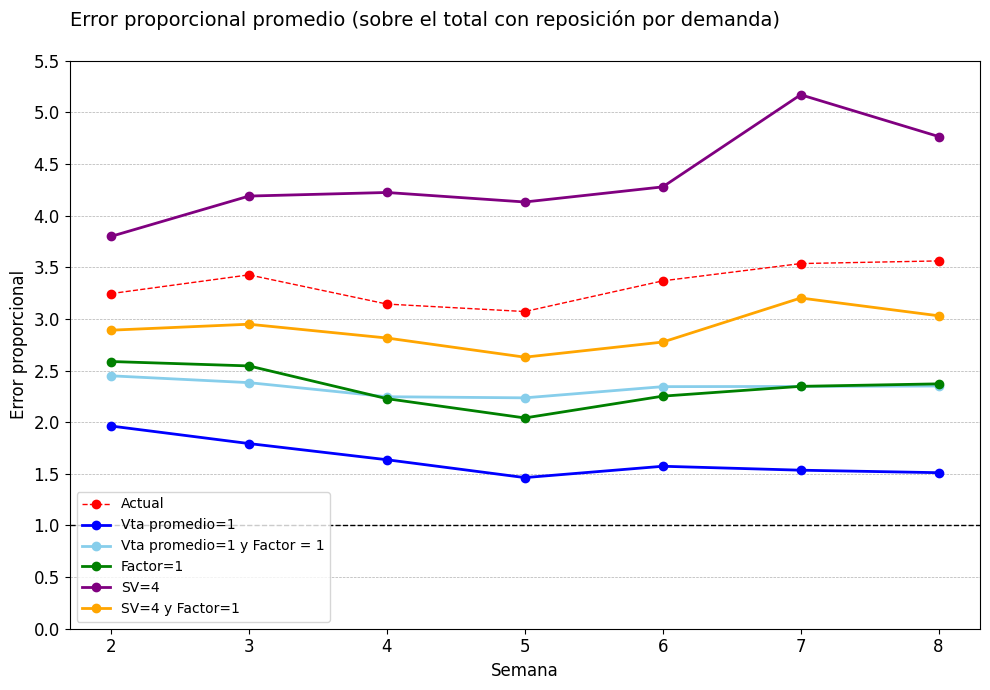

In [100]:
plt.figure(figsize=(10,7))

line1, = plt.plot(graph.index, graph["error_prop_tricot"], marker="o", label="Actual", color='red', linewidth=1, linestyle='--')
line2, = plt.plot(graph.index, graph["error_prop_vta_promedio"], marker="o", label="Vta promedio=1", color='blue', linewidth=2)
line3, = plt.plot(graph.index, graph["error_prop_vta_promedio_f1"], marker="o", label="Vta promedio=1 y Factor = 1", color='skyblue', linewidth=2)
line4, = plt.plot(graph.index, graph["error_prop_f1"], marker="o", label="Factor=1", color='green', linewidth=2)
line5, = plt.plot(graph.index, graph["error_prop_sv4"], marker="o", label="SV=4", color='purple', linewidth=2)
line6, = plt.plot(graph.index, graph["error_prop_sv4_f1"], marker="o", label="SV=4 y Factor=1", color='orange', linewidth=2)

plt.axhline(y=1, color="black", linestyle="--", linewidth=1,)

plt.yticks(np.arange(0, 6, 0.5), size=12)
plt.xticks(np.arange(2, 9), rotation=0, size=12)

plt.title("Error proporcional promedio (sobre el total con reposición por demanda)", size=14, loc='left', pad=25)
plt.xlabel("Semana", size=12)
plt.ylabel("Error proporcional", size=12)

plt.legend(handles=[line1, line2, line3, line4, line5, line6])

plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

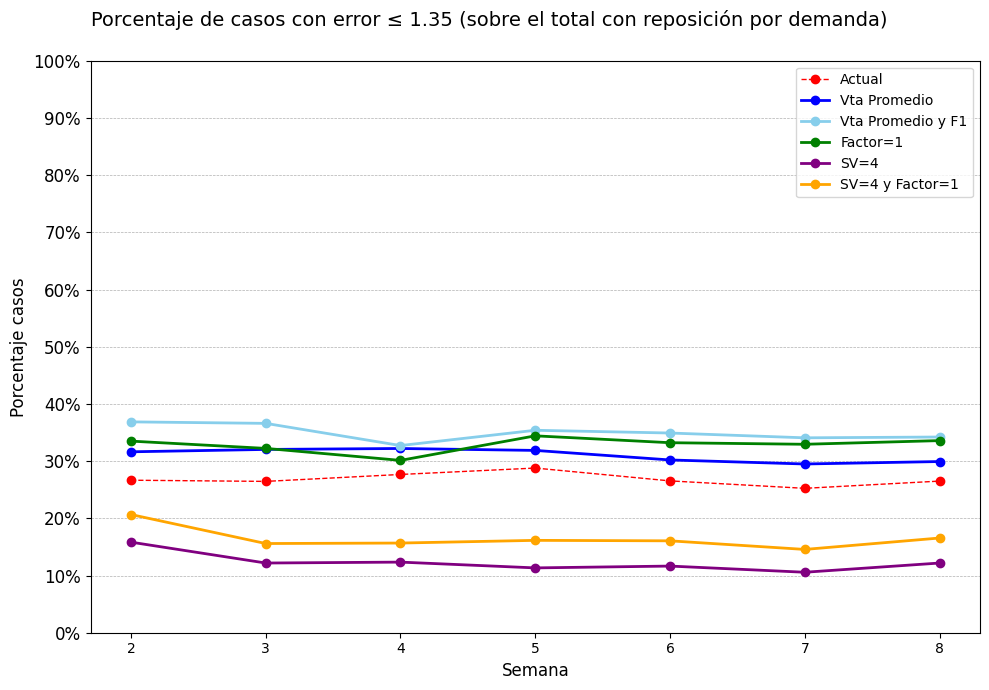

In [99]:
import matplotlib.ticker as mtick

plt.figure(figsize=(10,7))

line1, = plt.plot(graph.index, graph["flag_error_forecast_tricot_mean"], marker="o", label="Actual", color='red', linewidth=1, linestyle='--')
line2, = plt.plot(graph.index, graph["flag_error_forecast_vta_promedio_mean"], marker="o", label="Vta Promedio", color='blue', linewidth=2)
line3, = plt.plot(graph.index, graph["flag_error_forecast_vta_promedio_f1_mean"], marker="o", label="Vta Promedio y F1", color='skyblue', linewidth=2)
line4, = plt.plot(graph.index, graph["flag_error_forecast_f1_mean"], marker="o", label="Factor=1", color='green', linewidth=2)
line5, = plt.plot(graph.index, graph["flag_error_forecast_sv4_mean"], marker="o", label="SV=4", color='purple', linewidth=2)
line6, = plt.plot(graph.index, graph["flag_error_forecast_sv4_f1_mean"], marker="o", label="SV=4 y Factor=1", color='orange', linewidth=2)

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))

plt.yticks(np.arange(0, 1.1, 0.1), size=12)

plt.title(
    "Porcentaje de casos con error ≤ 1.35 (sobre el total con reposición por demanda)",
    size=14, loc='left', pad=25
)

plt.xlabel("Semana", size=12)
plt.ylabel("Porcentaje casos", size=12)

plt.legend(handles=[line1, line2, line3, line4, line5, line6])

plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.show()

## *Ejemplo*

In [116]:
condicion = 'tipo_error_forecast_tricot == "sobreestimando" and tipo_error_forecast_vta_promedio == "ok" and can_final > 0 and repo_x_dda > repo_x_ume'
data_all.query(condicion)[
    ['week_number','repo_x_dda','real_sales', 
     'forecast_tricot','forecast_vta_promedio','forecast_vta_promedio_f1', 
     'error_prop_forecast_tricot', 'error_prop_forecast_vta_promedio', 'error_prop_forecast_vta_promedio_f1',
     'flag_error_forecast_tricot', 'flag_error_forecast_vta_promedio', 'flag_error_forecast_vta_promedio_f1',
     'tipo_error_forecast_tricot','tipo_error_forecast_vta_promedio', 'tipo_error_forecast_vta_promedio_f1'
    ]].round(2)

,week_number,repo_x_dda,real_sales,forecast_tricot,forecast_vta_promedio,forecast_vta_promedio_f1,error_prop_forecast_tricot,error_prop_forecast_vta_promedio,error_prop_forecast_vta_promedio_f1,flag_error_forecast_tricot,flag_error_forecast_vta_promedio,flag_error_forecast_vta_promedio_f1,tipo_error_forecast_tricot,tipo_error_forecast_vta_promedio,tipo_error_forecast_vta_promedio_f1
330,2,9.0,11,19,10,8,1.73,0.91,0.73,0,1,1,sobreestimando,ok,ok
331,3,3.0,11,20,10,8,1.82,0.91,0.73,0,1,1,sobreestimando,ok,ok
1610,4,27.0,11,32,12,8,2.91,1.09,0.73,0,1,1,sobreestimando,ok,ok
2835,5,2.0,5,10,6,6,2.0,1.2,1.2,0,1,1,sobreestimando,ok,ok
6399,12,2.0,13,129,12,8,9.92,0.92,0.62,0,1,0,sobreestimando,ok,subestimando
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25835002,5,4.0,5,8,5,4,1.6,1.0,0.8,0,1,1,sobreestimando,ok,ok
25835248,3,8.0,6,19,4,4,3.17,0.67,0.67,0,1,1,sobreestimando,ok,ok
25835274,3,5.0,6,9,4,4,1.5,0.67,0.67,0,1,1,sobreestimando,ok,ok
25838585,2,66.0,9,67,10,4,7.44,1.11,0.44,0,1,0,sobreestimando,ok,subestimando


In [125]:
summary = (
    data_repo_x_dda
    .groupby('tipo_error_forecast_tricot', as_index=False)
    .agg(
        freq=('tipo_error_forecast_tricot', 'count'),
        error_mean=('error_prop_forecast_tricot', 'mean')
    )
).round(2)

# normalizar la frecuencia
summary['freq_pct'] = (summary['freq'] / summary['freq'].sum()).round(2)

display(summary.sort_values('tipo_error_forecast_tricot'))

/tmp/ipykernel_2867124/3678943877.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('tipo_error_forecast_tricot', as_index=False)


,tipo_error_forecast_tricot,freq,error_mean,freq_pct
0,ok,86490,1.03,0.26
1,sin venta,28109,<NA>,0.09
2,sobreestimando,202953,4.77,0.62
3,subestimando,10592,0.51,0.03


In [127]:
summary = (
    data_repo_x_dda
    .groupby('tipo_error_forecast_f1', as_index=False)
    .agg(
        freq=('tipo_error_forecast_f1', 'count'),
        error_mean=('error_prop_forecast_f1', 'mean')
    )
).round(2)

# normalizar la frecuencia
summary['freq_pct'] = (summary['freq'] / summary['freq'].sum()).round(2)

display(summary.sort_values('tipo_error_forecast_f1'))

/tmp/ipykernel_2867124/62252360.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('tipo_error_forecast_f1', as_index=False)


,tipo_error_forecast_f1,freq,error_mean,freq_pct
0,ok,106434,0.98,0.32
1,sin venta,28117,<NA>,0.09
2,sobreestimando,149397,4.06,0.46
3,subestimando,44196,0.47,0.13
